LAB 2: BÀI THỰC HÀNH TRÌNH BÀY DỮ LIỆU

Phần 1:

In [1]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("processed_dulieuxettuyendaihoc.csv")

# 1. Sắp xếp DH1 tăng dần
print(df.sort_values(by="DH1")[["STT","DH1"]].head())

# 2. Sắp xếp DH2 tăng dần theo nhóm giới tính
print(df.sort_values(by=["GT","DH2"])[["STT","GT","DH2"]].head())

# 3. Pivot-table DH1 theo KT
pivot1 = df.pivot_table(values="DH1", index="KT",
                        aggfunc=["count","sum","mean","median","min","max","std"])
print(pivot1)

# 4. Pivot-table DH1 theo KT và KV
pivot2 = df.pivot_table(values="DH1", index=["KT","KV"],
                        aggfunc=["count","sum","mean","median","min","max","std"])
print(pivot2)

# 5. Pivot-table DH1 theo KT, KV và DT
pivot3 = df.pivot_table(values="DH1", index=["KT","KV","DT"],
                        aggfunc=["count","sum","mean","median","min","max","std"])
print(pivot3)


    STT   DH1
53   54  1.00
43   44  1.25
5     6  1.50
72   73  1.50
83   84  1.75
    STT GT   DH2
95   96  F  1.50
25   26  F  2.00
24   25  F  2.25
46   47  F  2.25
13   14  F  2.75
   count     sum      mean median   min   max       std
     DH1     DH1       DH1    DH1   DH1   DH1       DH1
KT                                                     
A     49  163.50  3.336735   3.25  1.00  6.50  1.274296
A1     6   17.50  2.916667   3.00  2.00  4.25  0.861201
B      9   29.50  3.277778   3.50  1.75  4.50  0.823905
C     14   79.25  5.660714   5.25  4.75  7.00  0.812209
D1    22   84.25  3.829545   3.75  1.25  6.75  1.370146
       count    sum      mean median   min   max       std
         DH1    DH1       DH1    DH1   DH1   DH1       DH1
KT KV                                                     
A  1      29  93.75  3.232759  3.250  1.00  6.50  1.369194
   2       9  31.75  3.527778  3.500  2.00  6.25  1.427653
   2NT    11  38.00  3.454545  3.500  2.00  4.75  0.913908
A1 1       2

Phần 2:

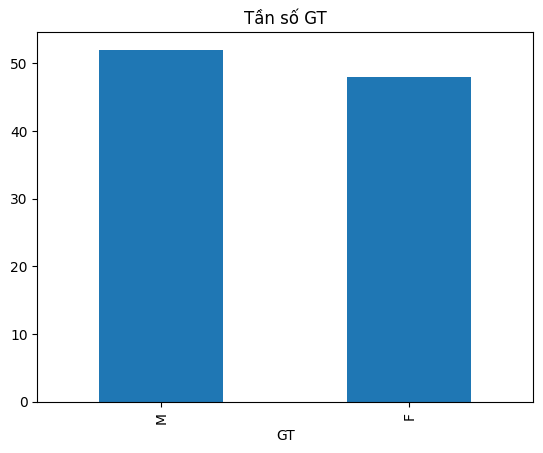

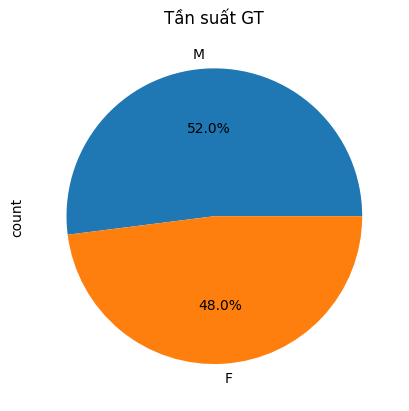

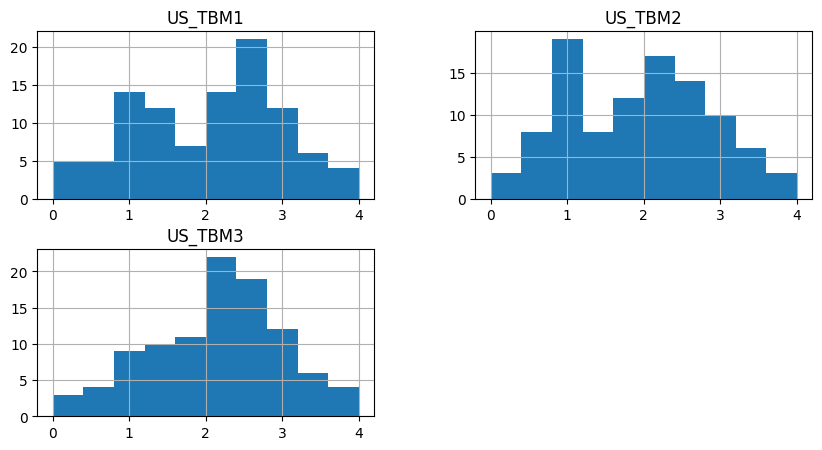

DT
0.0    50
1.0     1
6.0     1
Name: count, dtype: int64
KV
1      2
2      2
2NT    2
Name: count, dtype: int64
     DH1   DH2  DH3
23  6.75  5.25  5.0


In [2]:
import matplotlib.pyplot as plt

# 1. Biến GT
gt_counts = df["GT"].value_counts()
gt_counts.plot(kind="bar", title="Tần số GT")
plt.show()

gt_counts.plot(kind="pie", autopct="%1.1f%%", title="Tần suất GT")
plt.show()

# 2. US_TBM1, US_TBM2, US_TBM3
df[["US_TBM1","US_TBM2","US_TBM3"]].hist(figsize=(10,5))
plt.show()

# 3. Biến DT với học sinh nam
print(df[df["GT"]=="M"]["DT"].value_counts())

# 4. Biến KV với học sinh nam dân tộc Kinh, điều kiện điểm
cond = (df["GT"]=="M") & (df["DT"]==0) & (df["DH1"]>=5) & (df["DH2"]>=4) & (df["DH3"]>=4)
print(df[cond]["KV"].value_counts())

# 5. DH1, DH2, DH3 >= 5 và KV=2NT
cond2 = (df["DH1"]>=5) & (df["DH2"]>=5) & (df["DH3"]>=5) & (df["KV"]=="2NT")
print(df[cond2][["DH1","DH2","DH3"]].head())


Phần 3:

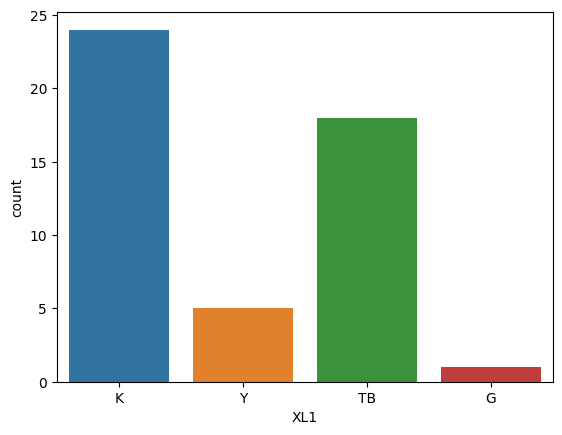

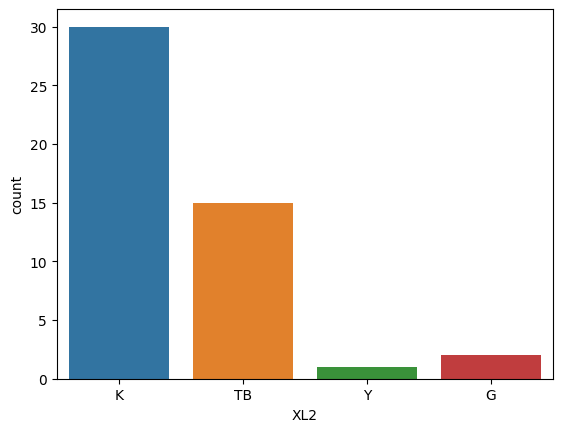

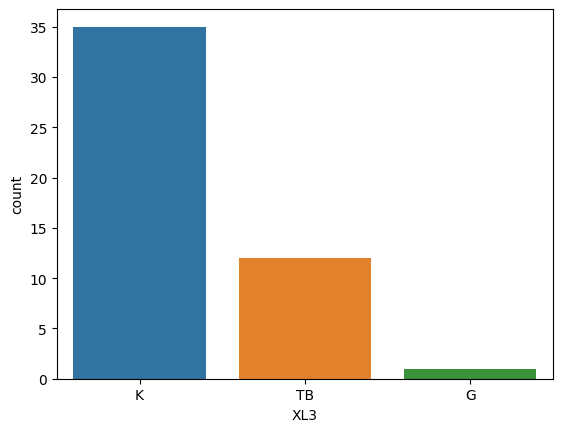

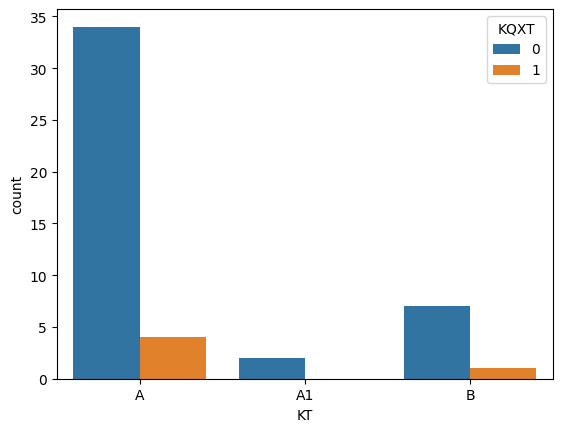

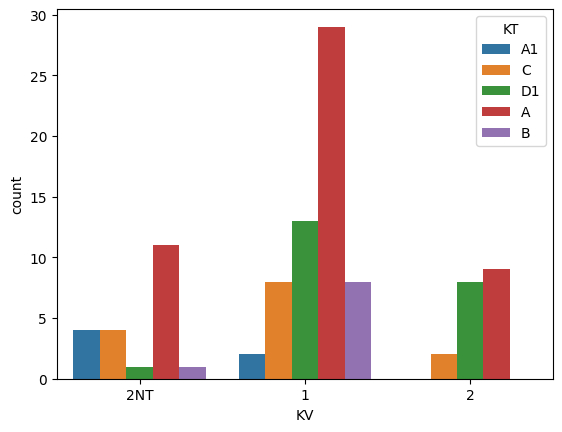

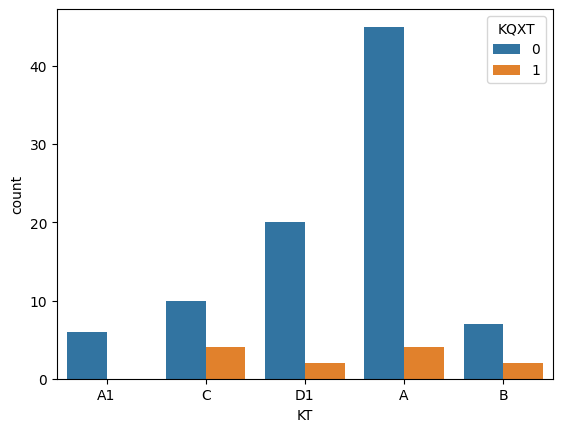

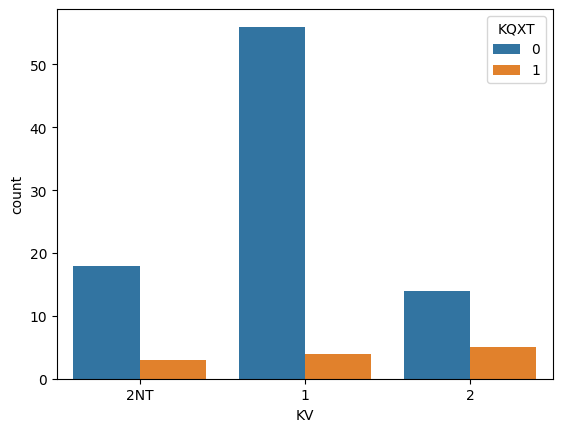

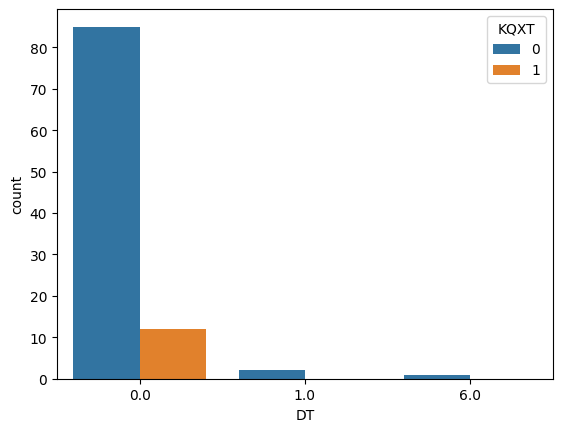

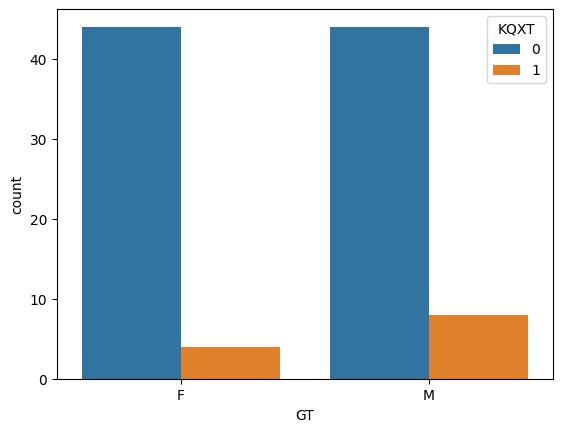

In [3]:
import seaborn as sns

# 1. Học sinh nữ theo XL1, XL2, XL3
female = df[df["GT"]=="F"]
sns.countplot(data=female, x="XL1", hue="XL1")
plt.show()
sns.countplot(data=female, x="XL2", hue="XL2")
plt.show()
sns.countplot(data=female, x="XL3", hue="XL3")
plt.show()

# 2. KQXT theo khối A, A1, B và KV 1,2
subset = df[(df["KT"].isin(["A","A1","B"])) & (df["KV"].isin(["1","2"]))]
sns.countplot(data=subset, x="KT", hue="KQXT")
plt.show()

# 3. Số lượng thí sinh từng KV theo KT
sns.countplot(data=df, x="KV", hue="KT")
plt.show()

# 4. Số lượng thí sinh đậu/rớt theo KT
sns.countplot(data=df, x="KT", hue="KQXT")
plt.show()

# 5. Đậu/rớt theo KV
sns.countplot(data=df, x="KV", hue="KQXT")
plt.show()

# 6. Đậu/rớt theo DT
sns.countplot(data=df, x="DT", hue="KQXT")
plt.show()

# 7. Đậu/rớt theo GT
sns.countplot(data=df, x="GT", hue="KQXT")
plt.show()


Phần 4:

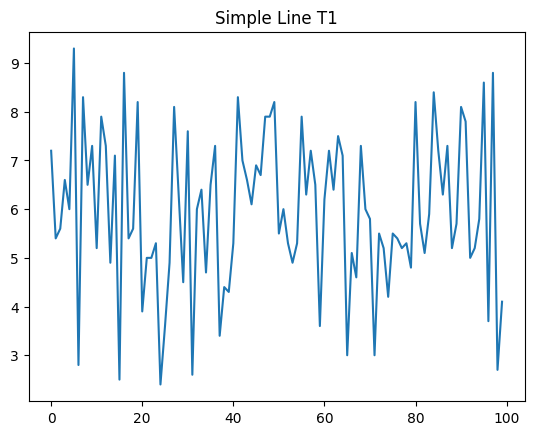

phanlopT1
tb     46
k      23
kha    19
g      12
Name: count, dtype: int64


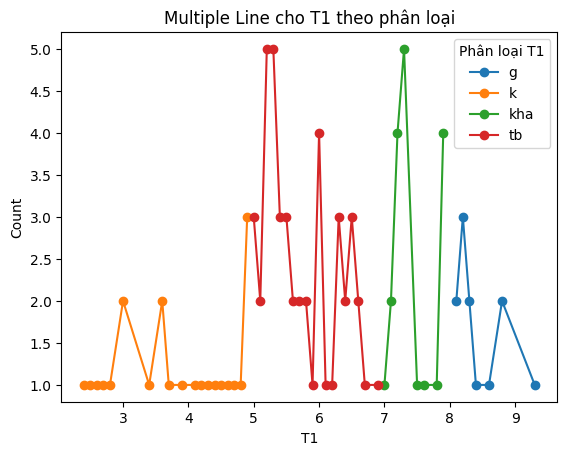

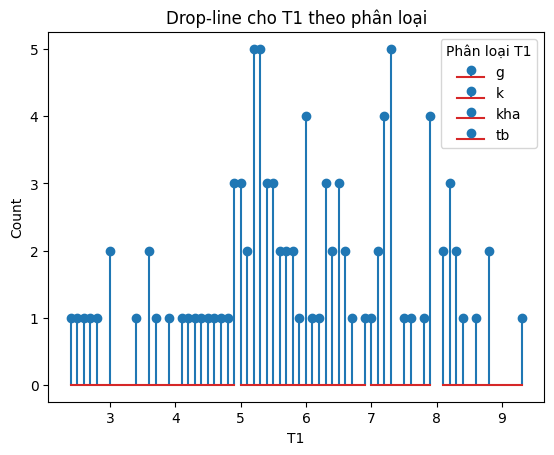

In [8]:
# 1. Biểu đồ đường Simple cho T1
df["T1"].plot(kind="line", title="Simple Line T1")
plt.show()

# 2. Phân loại T1
def classify_t1(x):
    if x < 5: return "k"
    elif x < 7: return "tb"
    elif x < 8: return "kha"
    else: return "g"
df["phanlopT1"] = df["T1"].apply(classify_t1)

# 3. Bảng tần số
print(df["phanlopT1"].value_counts())
# Fix: Define freq_table by grouping T1 values by their phanlopT1 category and counting them
freq_table = df.groupby(["phanlopT1", "T1"]).size().reset_index(name="Count")

# 4. Multiple Line theo phanlopT1
for cat in freq_table["phanlopT1"].unique():
    subset = freq_table[freq_table["phanlopT1"]==cat]
    plt.plot(subset["T1"], subset["Count"], marker="o", label=cat)

plt.xlabel("T1")
plt.ylabel("Count")
plt.title("Multiple Line cho T1 theo phân loại")
plt.legend(title="Phân loại T1")
plt.show()


# 5. Drop-line
for cat in freq_table["phanlopT1"].unique():
    subset = freq_table[freq_table["phanlopT1"]==cat]
    # Fix: Removed use_line_collection=True as it is deprecated in matplotlib >= 3.3
    plt.stem(subset["T1"], subset["Count"], label=cat)

plt.xlabel("T1")
plt.ylabel("Count")
plt.title("Drop-line cho T1 theo phân loại")
plt.legend(title="Phân loại T1")
plt.show()

Phần 5:

Trung bình: 5.946000000000001
Trung vị: 5.85
Độ lệch chuẩn: 1.6083381221470552
Min: 2.4 Max: 9.3


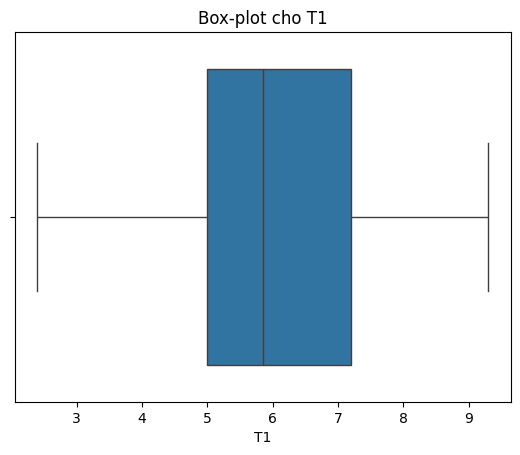

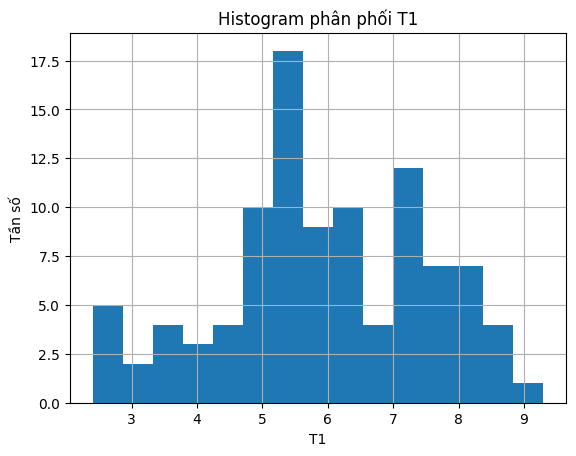

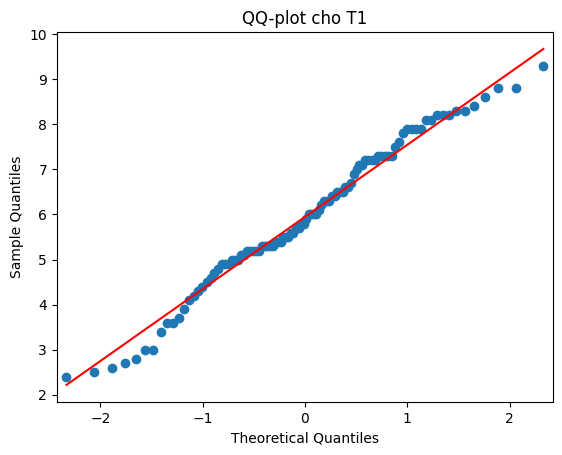

Skewness (độ lệch): -0.17824317486762223
Kurtosis (độ nhọn): -0.48010360836580634

Phân loại kha:
Trung bình: 7.421052631578948
Trung vị: 7.3
Độ lệch chuẩn: 0.31194541432832107


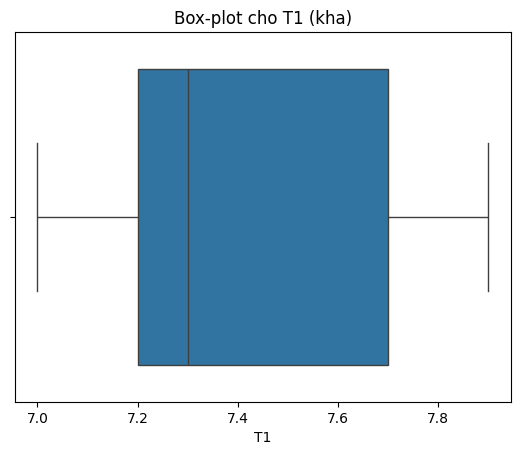

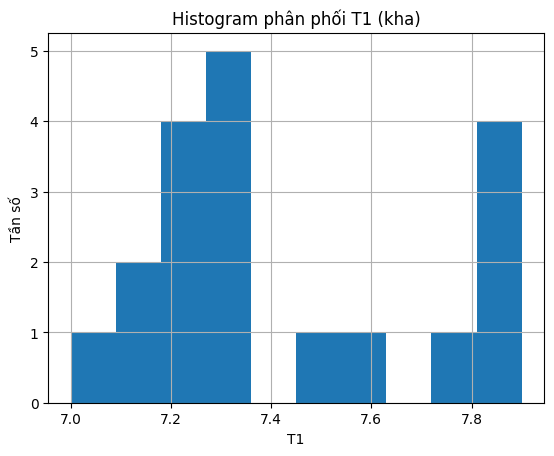

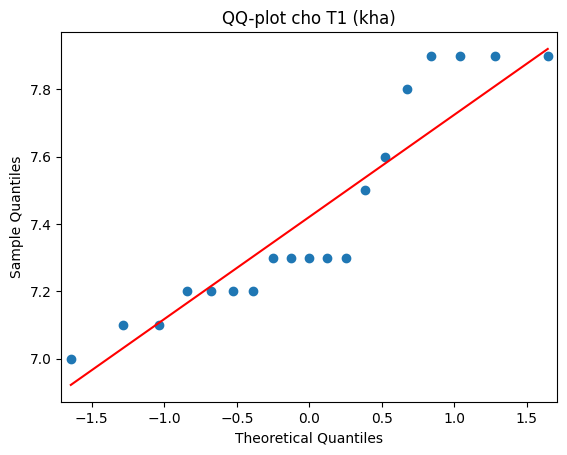


Phân loại tb:
Trung bình: 5.756521739130435
Trung vị: 5.65
Độ lệch chuẩn: 0.5451410312582906


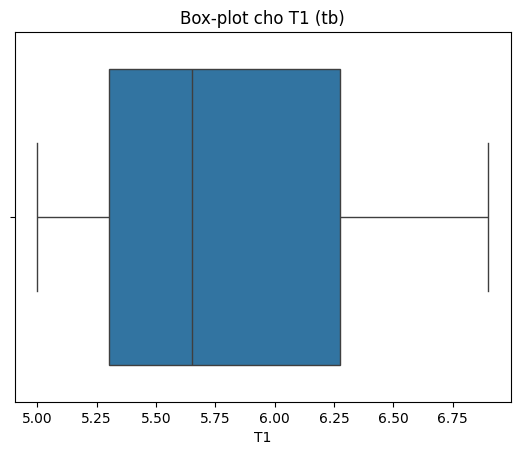

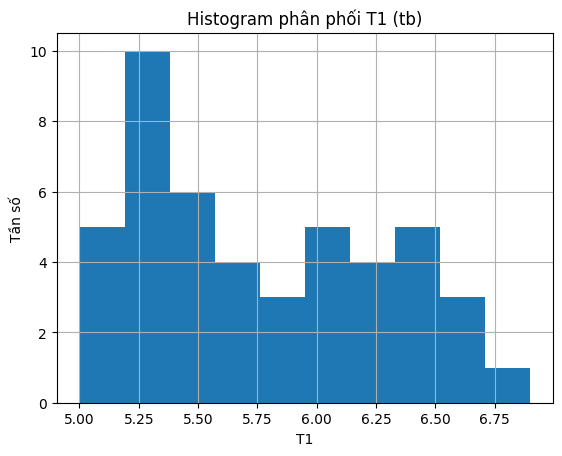

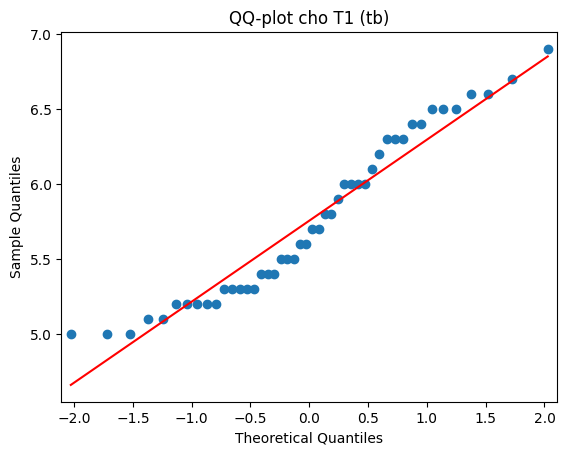


Phân loại g:
Trung bình: 8.441666666666666
Trung vị: 8.3
Độ lệch chuẩn: 0.36545944516540596


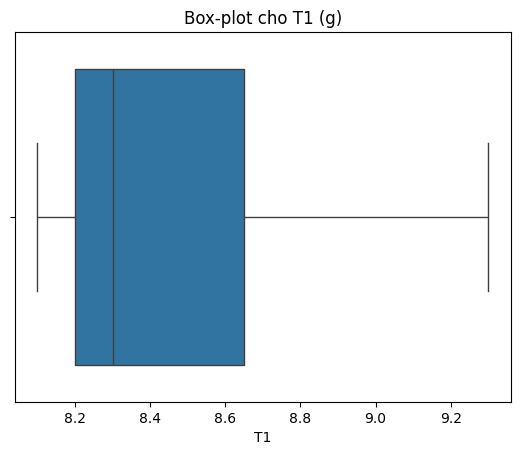

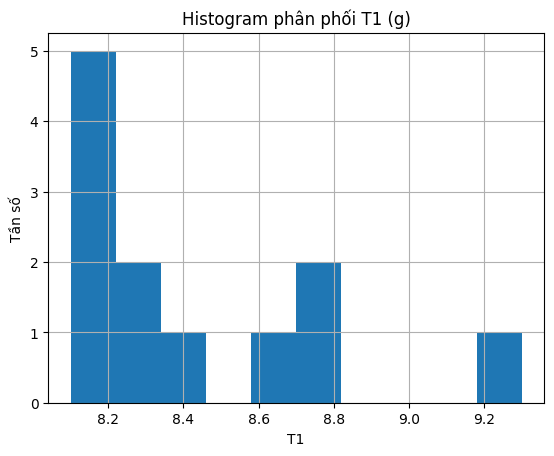

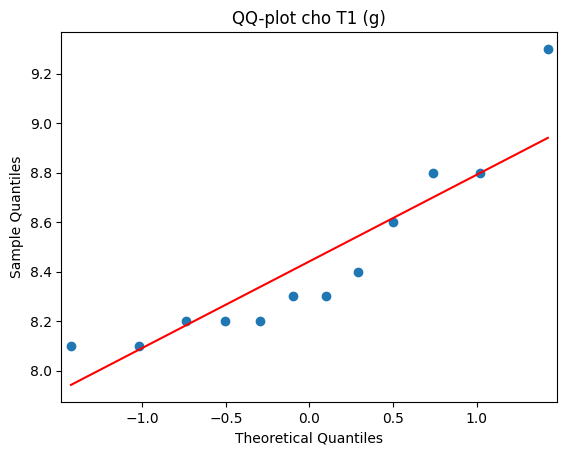


Phân loại k:
Trung bình: 3.8043478260869565
Trung vị: 3.9
Độ lệch chuẩn: 0.8599567964145669


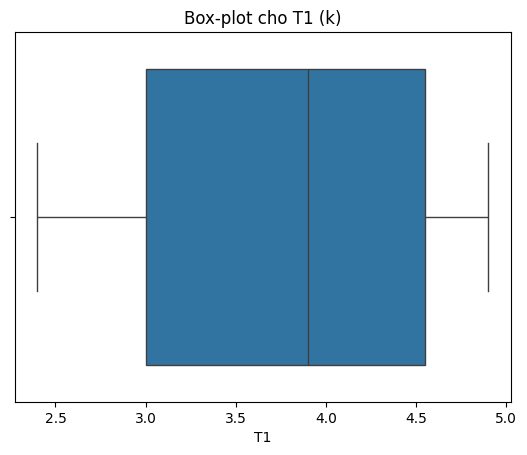

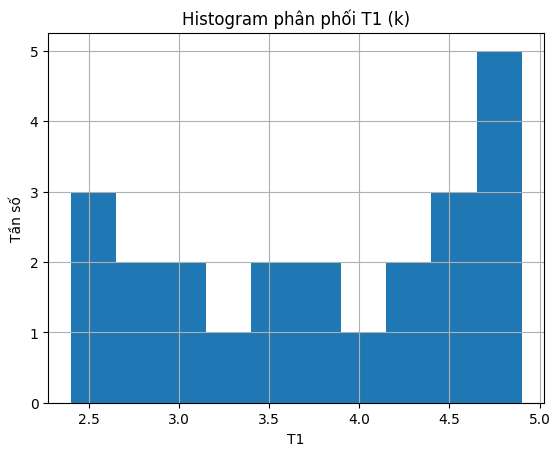

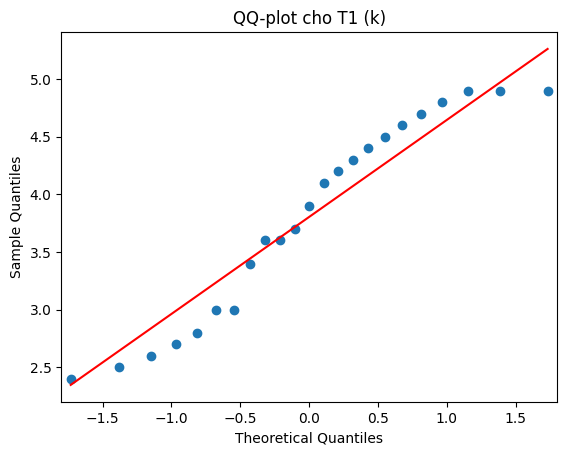

Covariance DH1-T1: 0.11283838383838381
Correlation DH1-T1: 0.049254392161041535


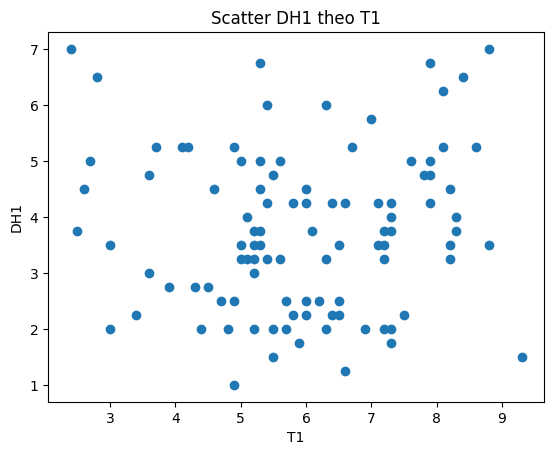

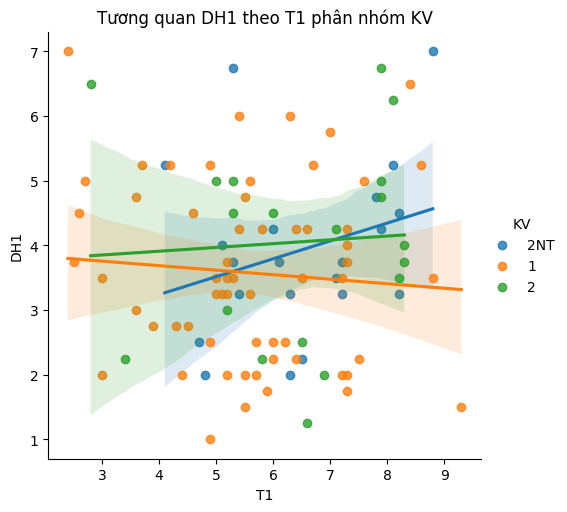

Ma trận tương quan:
           DH1       DH2       DH3
DH1  1.000000  0.035154  0.018731
DH2  0.035154  1.000000 -0.091523
DH3  0.018731 -0.091523  1.000000


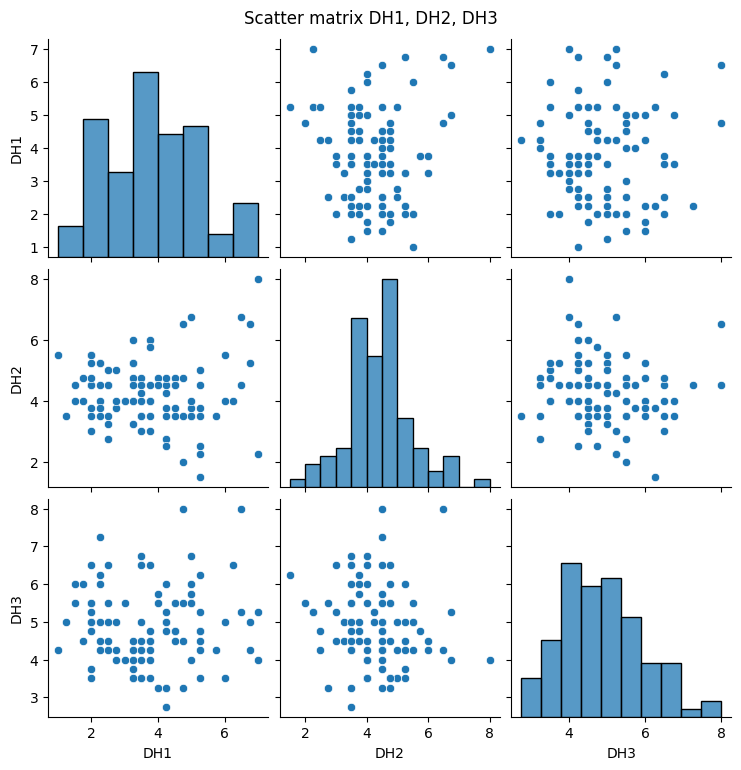

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Mô tả độ tập trung và phân tán của dữ liệu T1
print("Trung bình:", df["T1"].mean())
print("Trung vị:", df["T1"].median())
print("Độ lệch chuẩn:", df["T1"].std())
print("Min:", df["T1"].min(), "Max:", df["T1"].max())

# 2. Box-Plot cho T1
sns.boxplot(x=df["T1"])
plt.title("Box-plot cho T1")
plt.show()

# 3. Histogram cho T1
df["T1"].hist(bins=15)
plt.title("Histogram phân phối T1")
plt.xlabel("T1")
plt.ylabel("Tần số")
plt.show()

# 4. QQ-plot kiểm chứng phân phối chuẩn
sm.qqplot(df["T1"], line="s")
plt.title("QQ-plot cho T1")
plt.show()

# 5. Mô tả hình dáng lệch và nhọn
print("Skewness (độ lệch):", df["T1"].skew())
print("Kurtosis (độ nhọn):", df["T1"].kurt())

# 6. Mô tả và khảo sát phân phối cho T1 theo từng nhóm phanlopT1
for cat in df["phanlopT1"].unique():
    subset = df[df["phanlopT1"]==cat]
    print(f"\nPhân loại {cat}:")
    print("Trung bình:", subset["T1"].mean())
    print("Trung vị:", subset["T1"].median())
    print("Độ lệch chuẩn:", subset["T1"].std())

    # Box-plot
    sns.boxplot(x=subset["T1"])
    plt.title(f"Box-plot cho T1 ({cat})")
    plt.show()

    # Histogram
    subset["T1"].hist(bins=10)
    plt.title(f"Histogram phân phối T1 ({cat})")
    plt.xlabel("T1")
    plt.ylabel("Tần số")
    plt.show()

    # QQ-plot
    sm.qqplot(subset["T1"], line="s")
    plt.title(f"QQ-plot cho T1 ({cat})")
    plt.show()

# 7. Khảo sát tương quan giữa DH1 và T1
print("Covariance DH1-T1:", df[["DH1","T1"]].cov().iloc[0,1])
print("Correlation DH1-T1:", df[["DH1","T1"]].corr().iloc[0,1])

plt.scatter(df["T1"], df["DH1"])
plt.xlabel("T1")
plt.ylabel("DH1")
plt.title("Scatter DH1 theo T1")
plt.show()

# 8. Tương quan DH1 theo T1 trên từng nhóm KV
sns.lmplot(data=df, x="T1", y="DH1", hue="KV", fit_reg=True)
plt.title("Tương quan DH1 theo T1 phân nhóm KV")
plt.show()

# 9. Tương quan giữa DH1, DH2, DH3
print("Ma trận tương quan:\n", df[["DH1","DH2","DH3"]].corr())

sns.pairplot(df[["DH1","DH2","DH3"]])
plt.suptitle("Scatter matrix DH1, DH2, DH3", y=1.02)
plt.show()
